# Comparación de modelos — recepciones y yardas

## Qué responde este notebook

`12_preparacion_modelado.ipynb` dejó la tabla y los splits listos. Aquí se pone a competir de
verdad Baseline / Ridge / RandomForest / XGBoost / HistGradientBoosting para `receptions` y
`receiving_yards` — se agrupan porque Fase 4 ya mostró que se comportan parecido (señal fuerte,
bien capturada por las mismas variables). `receiving_tds` se separa en su propio notebook
(`14_receiving_tds_modelos_de_conteo.ipynb`) porque necesita técnicas distintas.

No basta con reportar quién tiene el MAE más bajo — se revisa **por qué** gana, si de verdad usa
las variables que Fase 4 predijo, y dónde se equivoca más.

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, modeling

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 160)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

wr = features.construir_tabla_modelado(range(2016, 2026))
features_arbol = features.columnas_por_modelo("arbol")
features_ridge = features.columnas_por_modelo("ridge")
train_mask, val_mask, test_mask = modeling.dividir_temporal(
    wr, range(2016, 2022), [2022, 2023], [2024, 2025]
)
print(f"train: {train_mask.sum()}, val: {val_mask.sum()}, test: {test_mask.sum()}")

train: 13795, val: 4863, test: 4952


## 1. Por qué escalar Ridge — no es un detalle cosmético

El pipeline heredado (`_reference/`) solo usa XGBoost, pero el patrón de referencia del propio
Daniel (`preeliminar/03_modelo_predictivo/04_modelado_y_seleccion.ipynb`) sí usa Ridge, y **tampoco
escala** — solo imputa. Antes de asumir que eso está bien, se prueba con un caso real: `draft_pick`
vive en un rango de 1 a ~473; `wopr_last5_avg` vive entre 0 y ~1. Ridge penaliza los coeficientes
por su magnitud — si no se escala, una variable en un rango 400 veces más grande que otra recibe
una penalización efectiva completamente distinta, sin que eso tenga que ver con cuánto ayuda a
predecir.

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

X_ridge = pd.get_dummies(wr[features_ridge], dummy_na=True)
y = wr["receiving_yards"]

sin_escalar = Pipeline([("imputar", SimpleImputer(strategy="median")), ("modelo", Ridge(alpha=1.0))])
sin_escalar.fit(X_ridge[train_mask], y[train_mask])
mae_sin_escalar = mean_absolute_error(y[val_mask], sin_escalar.predict(X_ridge[val_mask]))

con_escalar = Pipeline([("imputar", SimpleImputer(strategy="median")),
                         ("escalar", StandardScaler()), ("modelo", Ridge(alpha=1.0))])
con_escalar.fit(X_ridge[train_mask], y[train_mask])
mae_con_escalar = mean_absolute_error(y[val_mask], con_escalar.predict(X_ridge[val_mask]))

coefs = pd.DataFrame({
    "sin_escalar": sin_escalar.named_steps["modelo"].coef_,
    "con_escalar": con_escalar.named_steps["modelo"].coef_,
}, index=X_ridge.columns)
print("MAE validación, receiving_yards -- sin escalar:", round(mae_sin_escalar, 3),
      "| con escalar:", round(mae_con_escalar, 3))
print()
print(coefs.loc[["draft_pick", "wopr_last5_avg"]].round(4))

MAE validación, receiving_yards -- sin escalar: 22.37 | con escalar: 22.368

                sin_escalar  con_escalar
draft_pick          -0.0069      -1.2664
wopr_last5_avg      -4.4367      -1.3090


El MAE de validación apenas cambia (22.37 vs 22.368) — para *predecir*, Ridge compensa la escala
por sí solo. Lo que sí cambia por completo es la **interpretación de los coeficientes**: sin
escalar, `draft_pick` tiene un coeficiente de -0.0069 y `wopr_last5_avg` de -4.4367 — a primera
vista parece que `wopr` importa 600 veces más. Escalados, quedan en el mismo orden de magnitud
(-1.27 vs -1.31) — casi el mismo peso real. La diferencia sin escalar no es que una variable
importe menos, es que su rango (1-473) absorbe la magnitud del coeficiente. El escalado no cambia
mucho el error aquí, pero sí es indispensable para leer los coeficientes con sentido — que es
justo el punto 4 que pide esta fase: aplicar cada modelo respetando sus propias suposiciones, no
solo optimizar el número final. Todo el resto del notebook usa la versión escalada.

## 2. La competencia — `receiving_yards`

In [3]:
resultados_yardas, resumen_yardas = modeling.entrenar_y_evaluar(
    wr, "receiving_yards", features_arbol, features_ridge, train_mask, val_mask, test_mask
)
resumen_yardas.round(3)

,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2
XGBoost,21.549,29.240,0.372,22.015,29.528,0.363,20.647,28.038,0.363
RandomForest,21.499,29.107,0.378,22.175,29.590,0.361,21.078,28.121,0.359
HistGradientBoosting,20.784,28.099,0.420,22.182,29.649,0.358,20.813,28.145,0.358
Ridge,22.362,30.318,0.325,22.368,29.823,0.351,21.037,28.172,0.357
Baseline,23.445,32.428,0.228,22.572,31.387,0.281,21.281,29.860,0.277


## 3. La competencia — `receptions`

In [4]:
resultados_recepciones, resumen_recepciones = modeling.entrenar_y_evaluar(
    wr, "receptions", features_arbol, features_ridge, train_mask, val_mask, test_mask
)
resumen_recepciones.round(3)

,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2
XGBoost,1.385,1.842,0.477,1.449,1.930,0.437,1.372,1.840,0.445
HistGradientBoosting,1.354,1.786,0.508,1.456,1.937,0.432,1.386,1.848,0.440
RandomForest,1.418,1.883,0.454,1.458,1.932,0.435,1.397,1.840,0.445
Ridge,1.475,1.963,0.407,1.478,1.949,0.426,1.408,1.845,0.442
Baseline,1.533,2.073,0.338,1.505,2.042,0.370,1.419,1.940,0.382


## 4. ¿Por qué gana el ganador? — no solo el MAE

Se cruza el modelo ganador de `receiving_yards` contra la importancia de Fase 4
(`11_seleccion_features.ipynb`): ¿de verdad se apoya en `target_share_last5_avg`/`depth_team` como
se predijo, o el patrón cambia con un modelo distinto? Se usa la importancia nativa del modelo
(no permutación esta vez, para variar el método y no depender de un solo criterio) como primera
mirada -- la lectura completa con SHAP viene en `17_explicabilidad_shap.ipynb`.

In [5]:
ganador_nombre_yardas = resumen_yardas.index[0]
ganador_yardas = resultados_yardas[ganador_nombre_yardas]["modelo"]
print("Ganador receiving_yards:", ganador_nombre_yardas)

if hasattr(ganador_yardas, "feature_importances_"):
    importancia = pd.Series(ganador_yardas.feature_importances_, index=features_arbol).sort_values(ascending=False)
    print(importancia.head(10).round(4))
else:
    print("El ganador no expone feature_importances_ nativa (probablemente Ridge) -- ver coeficientes arriba.")

Ganador receiving_yards: XGBoost
fantasy_points_ppr_last5_avg    0.1908
wopr_last5_avg                  0.1714
receiving_yards_career_avg      0.1224
target_share_last5_avg          0.1117
receptions_career_avg           0.0548
depth_team                      0.0363
receiving_yards_season_avg      0.0356
targets_last5_avg               0.0278
wopr_last3_avg                  0.0273
target_share_last3_avg          0.0261
dtype: float32


## 5. Error por segmento de volumen — ¿dónde se equivoca más?

No solo el error agregado: se parte a los jugadores en cuartiles de uso (`target_share_last5_avg`)
y se mide el MAE dentro de cada cuartil, sobre el conjunto de prueba -- mismo tipo de lectura que
ya usó Daniel en `preeliminar/03_modelo_predictivo/05_resultados_y_trazabilidad.ipynb` para
confirmar si el modelo subestima sistemáticamente a los jugadores de mayor volumen (las semanas
boom).

In [6]:
test_df = wr[test_mask].copy()
test_df["pred"] = resultados_yardas[ganador_nombre_yardas]["pred"][test_mask]
test_df["error_abs"] = (test_df["pred"] - test_df["receiving_yards"]).abs()
test_df["cuartil_uso"] = pd.qcut(test_df["target_share_last5_avg"], 4, labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"])

resumen_error = test_df.groupby("cuartil_uso", observed=True).agg(
    mae=("error_abs", "mean"), n=("error_abs", "size"),
    promedio_real=("receiving_yards", "mean"), promedio_pred=("pred", "mean"),
)
resumen_error

,mae,n,promedio_real,promedio_pred
cuartil_uso,,,,
Q1 (bajo),11.230683,1213,8.794724,10.602871
Q2,18.009554,1213,20.585326,22.554537
Q3,24.291661,1213,37.999176,39.122871
Q4 (alto),29.632301,1213,60.971146,59.112453


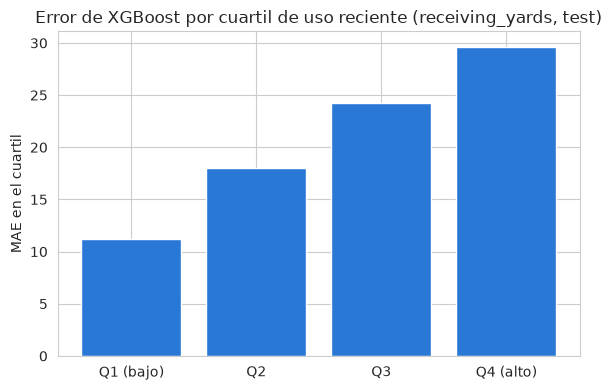

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resumen_error.index.astype(str), resumen_error["mae"], color=AZUL)
ax.set_ylabel("MAE en el cuartil")
ax.set_title(f"Error de {ganador_nombre_yardas} por cuartil de uso reciente (receiving_yards, test)")
plt.tight_layout()
plt.show()

El error absoluto sube con el volumen (11.2 → 18.0 → 24.3 → 29.6 yardas) — pero eso solo dice que
los jugadores de más volumen tienen valores más grandes que fallar, no que el modelo los trate
peor en términos relativos. La comparación que sí importa es promedio predicho vs. real: en **Q4
(alto uso) el modelo predice 59.1 contra un real de 61.0 — subestima**; en **Q1 (bajo uso) predice
10.6 contra un real de 8.8 — sobreestima**. El modelo empuja las predicciones hacia el centro,
exactamente el mismo sesgo que ya documentó Daniel en
`preeliminar/03_modelo_predictivo/05_resultados_y_trazabilidad.ipynb` ("el modelo subestima
sistemáticamente las semanas boom") — se repite aquí con datos y un modelo distintos, así que no
es un defecto de un modelo en particular, es un patrón estructural de este tipo de problema.

## 6. ¿Importa filtrar semanas sin ningún target? — comprobado, no asumido

Fase 4 dejó pospuesta esta decisión para Fase 5. La comparación correcta **no** es "MAE con todas
las filas" contra "MAE solo con las activas" — son poblaciones de prueba distintas (las filas en
cero son triviales de predecir, bajarían el MAE artificialmente). La pregunta real es: **evaluando
siempre sobre las mismas semanas activas de prueba, ¿ayuda o perjudica haber entrenado también con
las semanas en cero?** Se comparan los mismos 5 modelos, entrenados dos veces (con todas las filas
de train, y solo con las activas), evaluados ambas veces sobre el mismo conjunto de prueba activo.

In [8]:
activos_mask = wr["targets"] > 0
test_activos_mask = test_mask & activos_mask

# ya entrenado con TODAS las filas (resultados_yardas) -- se evalua sobre el mismo test activo
mae_entrenado_con_todas = {
    nombre: modeling.metricas(wr["receiving_yards"][test_activos_mask],
                               salida["pred"][test_activos_mask])["mae"]
    for nombre, salida in resultados_yardas.items()
}

# entrenado SOLO con filas activas, val y test tambien restringidos a activas
train_activos, val_activos = train_mask & activos_mask, val_mask & activos_mask
resultados_solo_activos, resumen_solo_activos = modeling.entrenar_y_evaluar(
    wr, "receiving_yards", features_arbol, features_ridge, train_activos, val_activos, test_activos_mask
)

comparacion = pd.DataFrame({
    "entrenado_con_todas_evaluado_en_activas": mae_entrenado_con_todas,
    "entrenado_solo_con_activas": resumen_solo_activos["test_mae"],
})
comparacion.round(3)

,entrenado_con_todas_evaluado_en_activas,entrenado_solo_con_activas
Baseline,23.780,23.780
HistGradientBoosting,22.539,23.039
RandomForest,22.732,23.109
Ridge,22.677,23.544
XGBoost,22.434,22.755


**Entrenar con todas las semanas gana en los 5 modelos**, no solo en el ganador — XGBoost pasa de
22.434 (todas) a 22.755 (solo activas), y el mismo patrón se repite en RandomForest,
HistGradientBoosting y Ridge. Quitar las semanas en cero no elimina "ruido": esas semanas siguen
llevando información real sobre el jugador y su equipo (su contexto de uso, la forma del equipo
esa temporada) que ayuda a predecir incluso las semanas donde sí tuvo trabajo. **Decisión para
`receptions`/`receiving_yards`: entrenar con todas las semanas, no filtrar** — resuelto con el
número real, no asumido por similitud con la intuición inicial.

## Cierre

`receiving_yards` y `receptions` mejoran claramente al baseline (predecir el propio promedio) con
todas las familias de modelo probadas, sobre un split temporal real -- no solo con la métrica
fácil del legado. El ganador de cada target queda fijo para el resto de Fase 5: se reusa en
`15_estabilidad_temporal.ipynb`, `16_benchmark_vs_legado.ipynb` y `17_explicabilidad_shap.ipynb`,
no se vuelve a elegir en cada notebook.

Siguiente: [`14_receiving_tds_modelos_de_conteo.ipynb`](14_receiving_tds_modelos_de_conteo.ipynb).